# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [ ]:
# !pip install peft==0.13.2 transformers==4.41.1

In [ ]:
# !pip install wordcloud

In [ ]:
# !pip install imblearn

In [ ]:
# !pip install lightgbm

In [ ]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from typing import Any, Dict, Tuple, Optional

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    f1_score, roc_curve, auc, accuracy_score,
)
from sklearn.utils import resample, shuffle

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer, AutoModel,
    AlbertModel, AlbertTokenizer,
    BertTokenizer,
)

# ── Notebook setup ───────────────────────────────────────
warnings.filterwarnings("ignore")


## 1.2 Seed \& Device

In [ ]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 1.3 Configuration

In [ ]:
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights"
RAW_DATA_FILE = "data/drugscom_plus_ai_labels.csv"
OUTPUT_DIR = "outputs_text_only_soft_train"

ALBERT_MODEL_NAME = "albert-base-v2"
BIOBERT_MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"

TEXT_COLUMN = "review"

# ── 3-class sentiment ────────────────────────────────────
CLASS_NAMES = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
NUM_CLASSES = len(CLASS_NAMES)

# ── Aspect config ────────────────────────────────────────
ASPECT_COLS = ["ai_efficacy", "ai_safety", "ai_burden", "ai_cost"]
ASPECT_WEIGHTS = {
    "ai_efficacy": 1.0,
    "ai_safety":   1.0,
    "ai_burden":   1.0,
    "ai_cost":     1.0,
}
POLARITY_MAP = {"POSITIVE": 1, "NEUTRAL": 0, "NEGATIVE": -1}

# ── Training config ──────────────────────────────────────
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
PATIENCE = 3
NUM_WORKERS = 2

# ── A100 optimizations ──────────────────────────────────
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
print(f"BF16: {USE_BF16}")

# ── Retrain flag ─────────────────────────────────────────
RETRAIN = True

# ── Derived paths ────────────────────────────────────────
RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "albert": {
        "model":  OUTPUT_PATH / "best_albert_soft3class.pth",
        "params": OUTPUT_PATH / "best_albert_soft3class_params.json",
    },
    "biobert": {
        "model":  OUTPUT_PATH / "best_biobert_soft3class.pth",
        "params": OUTPUT_PATH / "best_biobert_soft3class_params.json",
    },
}

print("--- R1 3-Class Soft-Label Configuration (Uniform 1:1:1:1; soft-train only) ---")
print(f"  Project    : {DRIVE_PROJECT_PATH}")
print(f"  Classes    : {CLASS_NAMES}")
print(f"  Aspect wts : {ASPECT_WEIGHTS}")

BF16: True
--- R1 3-Class Soft-Label Configuration (Uniform 1:1:1:1; soft-train only) ---
  Project    : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights
  Classes    : ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
  Aspect wts : {'ai_efficacy': 1.0, 'ai_safety': 1.0, 'ai_burden': 1.0, 'ai_cost': 1.0}


## 1.4 Mount drive & Load the data

In [ ]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0).reset_index()
print(f"Loaded {df_raw.shape[0]} rows.")

Mounted at /content/drive/
Loaded 102061 rows.


In [ ]:
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)

# 2. Data Exploration \& Master Data Preparation

## 2.1 Master Data Preparation

### 2.1.1 Text cleaning

In [ ]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


### 2.1.2 Validate soft labels

In [ ]:
print("\nValidating aspect labels...")
for asp in ASPECT_COLS:
    if asp not in df_clean.columns:
        raise ValueError(f"Missing column: {asp}")
    df_clean[asp] = df_clean[asp].str.upper().str.strip()
    df_clean[asp] = df_clean[asp].replace({
        "VERY_POSITIVE": "POSITIVE",
        "VERY_NEGATIVE": "NEGATIVE",
    })
    valid_mask = df_clean[asp].isin(["POSITIVE", "NEUTRAL", "NEGATIVE"])
    n_invalid = (~valid_mask).sum()
    if n_invalid > 0:
        print(f"  WARNING: {asp} has {n_invalid} invalid values — setting to NEUTRAL")
        df_clean.loc[~valid_mask, asp] = "NEUTRAL"
    print(f"  {asp}: {df_clean[asp].value_counts().to_dict()}")


Validating aspect labels...
  ai_efficacy: {'POSITIVE': 66326, 'NEGATIVE': 27971, 'NEUTRAL': 7764}
  ai_safety: {'NEGATIVE': 40703, 'NEUTRAL': 34519, 'POSITIVE': 26839}
  ai_burden: {'NEUTRAL': 54537, 'NEGATIVE': 34262, 'POSITIVE': 13262}
  ai_cost: {'NEUTRAL': 92376, 'NEGATIVE': 6474, 'POSITIVE': 3211}


### 2.1.3 Derive 3-class soft labels from aspect votes

In [ ]:
print("\nDeriving 3-class soft labels from aspect votes (1111 weights)...")

soft_3class = np.zeros((len(df_clean), 3), dtype=np.float32)  # [NEG, NEU, POS]

for asp in ASPECT_COLS:
    w = ASPECT_WEIGHTS[asp]
    neg_mask = (df_clean[asp] == "NEGATIVE").values
    neu_mask = (df_clean[asp] == "NEUTRAL").values
    pos_mask = (df_clean[asp] == "POSITIVE").values
    soft_3class[neg_mask, 0] += w
    soft_3class[neu_mask, 1] += w
    soft_3class[pos_mask, 2] += w

# Normalize rows to sum to 1
row_sums = soft_3class.sum(axis=1, keepdims=True)
soft_3class = soft_3class / np.clip(row_sums, 1e-8, None)

# Store in dataframe
df_clean["soft_neg"] = soft_3class[:, 0]
df_clean["soft_neu"] = soft_3class[:, 1]
df_clean["soft_pos"] = soft_3class[:, 2]

# Hard label from soft (for stratification & evaluation)
df_clean["y_hard_3class"] = soft_3class.argmax(axis=1)
df_clean["y_hard_3class_name"] = df_clean["y_hard_3class"].map(
    {i: CLASS_NAMES[i] for i in range(NUM_CLASSES)}
)

print("\n3-class hard label distribution (argmax of soft):")
print(df_clean["y_hard_3class_name"].value_counts())

# Entropy analysis
hard = soft_3class.argmax(axis=1)
for i, name in enumerate(CLASS_NAMES):
    mask = (hard == i)
    if mask.sum() == 0:
        continue
    class_soft = soft_3class[mask]
    own_prob = class_soft[:, i].mean()
    entropy = -(class_soft * np.log(np.clip(class_soft, 1e-8, 1))).sum(axis=1).mean()
    print(f"{name:10s} | n={mask.sum():5d} | own_prob={own_prob:.3f} | entropy={entropy:.3f}")



Deriving 3-class soft labels from aspect votes (1111 weights)...

3-class hard label distribution (argmax of soft):
y_hard_3class_name
NEUTRAL     54467
NEGATIVE    35057
POSITIVE    12537
Name: count, dtype: int64
NEGATIVE   | n=35057 | own_prob=0.654 | entropy=0.657
NEUTRAL    | n=54467 | own_prob=0.626 | entropy=0.684
POSITIVE   | n=12537 | own_prob=0.739 | entropy=0.575


In [ ]:
# Entropy analysis
hard = soft_3class.argmax(axis=1)
for i, name in enumerate(CLASS_NAMES):
    mask = (hard == i)
    if mask.sum() == 0:
        continue
    class_soft = soft_3class[mask]
    own_prob = class_soft[:, i].mean()
    entropy = -(class_soft * np.log(np.clip(class_soft, 1e-8, 1))).sum(axis=1).mean()
    print(f"{name:10s} | n={mask.sum():5d} | own_prob={own_prob:.3f} | entropy={entropy:.3f}")


NEGATIVE   | n=35057 | own_prob=0.654 | entropy=0.657
NEUTRAL    | n=54467 | own_prob=0.626 | entropy=0.684
POSITIVE   | n=12537 | own_prob=0.739 | entropy=0.575


## 2.2 Master Data Split

In [ ]:
groups = df_clean[TEXT_COLUMN]
y_for_split = df_clean["y_hard_3class"]

# 80/20 → train+val / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y_for_split, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# train → train + val (75/25 of 80% = 60/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval["y_hard_3class"],
                  groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("\nSplit counts:")
print(df_clean["split"].value_counts())

# Leakage check
group_split_nunique = df_clean.groupby(TEXT_COLUMN)["split"].nunique()
n_leaky = (group_split_nunique > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print("Leakage check passed.")

# Save
split_path = OUTPUT_PATH / "master_split_soft3class.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved master split → {split_path}")


Split counts:
split
train    61309
test     20383
val      20369
Name: count, dtype: int64
Leakage check passed.
Saved master split → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only_soft_train/master_split_soft3class.csv


# 3. ALBERT \& BioBERT Models (soft training \& hard validation + test)

## 3.1 Shared helper functions

In [ ]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx],
                              average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def plot_confusion_matrix(y_true, y_pred, class_names, title="Model", save_dir=None):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, class_names, title="Model", save_dir=None):
    y_true_bin = label_binarize(np.asarray(y_true, dtype=int),
                                classes=np.arange(len(class_names)))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", len(class_names))
    plt.figure(figsize=(10, 8))
    for i, (name, color) in enumerate(zip(class_names, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{name} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

## 3.2 Data splits \& labels

In [ ]:
SOFT_3CLASS_COLS = ["soft_neg", "soft_neu", "soft_pos"]

def _extract_soft_3class(df: pd.DataFrame) -> np.ndarray:
    s = df[SOFT_3CLASS_COLS].to_numpy(dtype=np.float32)
    return s / np.clip(s.sum(axis=1, keepdims=True), 1e-8, None)


df_train = df_clean[df_clean["split"] == "train"].copy()
df_val   = df_clean[df_clean["split"] == "val"].copy()
df_test  = df_clean[df_clean["split"] == "test"].copy()

train_texts = df_train[TEXT_COLUMN].astype(str).tolist()
val_texts   = df_val[TEXT_COLUMN].astype(str).tolist()
test_texts  = df_test[TEXT_COLUMN].astype(str).tolist()

# Soft labels for training, hard labels for val/test evaluation
y_train_soft = _extract_soft_3class(df_train)
y_val_hard   = _extract_soft_3class(df_val).argmax(axis=1).astype(np.int64)
y_test_hard  = _extract_soft_3class(df_test).argmax(axis=1).astype(np.int64)

print(f"Train soft: {y_train_soft.shape}")
print(f"Val  hard : {np.bincount(y_val_hard, minlength=NUM_CLASSES)}")
print(f"Test hard : {np.bincount(y_test_hard, minlength=NUM_CLASSES)}")


Train soft: (61309, 3)
Val  hard : [ 6915 10867  2587]
Test hard : [ 6970 10940  2473]


## 3.3 Generic soft-label model componets

In [ ]:
# ── Pre-tokenization ─────────────────────────────────────
def batch_tokenize(texts, tokenizer, max_len):
    enc = tokenizer(
        [str(t) for t in texts],
        truncation=True, padding="max_length",
        max_length=max_len, return_tensors="pt",
    )
    return enc["input_ids"], enc["attention_mask"]


# ── Dataset ──────────────────────────────────────────────
class SoftLabelDataset(Dataset):
    """Pre-tokenized dataset with optional soft and hard labels."""

    def __init__(self, input_ids, attention_masks,
                 hard_labels=None, soft_labels=None):
        self.input_ids = input_ids
        self.attention_masks = attention_masks

        self.soft_labels = None
        if soft_labels is not None:
            sl = np.asarray(soft_labels, dtype=np.float32)
            rs = sl.sum(axis=1, keepdims=True)
            self.soft_labels = sl / np.clip(rs, 1e-8, None)

        self.hard_labels = None
        if hard_labels is not None:
            self.hard_labels = np.asarray(hard_labels, dtype=np.int64)
        elif self.soft_labels is not None:
            self.hard_labels = self.soft_labels.argmax(axis=1).astype(np.int64)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        item = {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_masks[idx],
        }
        if self.hard_labels is not None:
            item["labels"] = torch.tensor(self.hard_labels[idx], dtype=torch.long)
        if self.soft_labels is not None:
            item["soft_labels"] = torch.tensor(self.soft_labels[idx], dtype=torch.float32)
        return item


# ── Classifier ───────────────────────────────────────────
class TransformerClassifier(nn.Module):
    """Base transformer → dropout → linear → logits (3-class)."""

    def __init__(self, base_model, hidden_size, num_classes=NUM_CLASSES,
                 dropout=0.1):
        super().__init__()
        self.base = base_model
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.base(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.fc(self.dropout(cls))


# ── Loss function ────────────────────────────────────────
def weighted_soft_cross_entropy(logits, soft_targets, class_weights=None):
    """Soft-label CE, optionally weighted per class."""
    log_probs = torch.log_softmax(logits, dim=1)
    loss = -(soft_targets * log_probs)
    if class_weights is not None:
        loss = loss * class_weights.view(1, -1)
    return loss.sum(dim=1).mean()


# ── Inference helper ─────────────────────────────────────
def predict_logits(model, loader, device=DEVICE):
    """Run inference, return (logits, hard_labels, soft_labels) as numpy."""
    model.eval()
    all_logits, all_labels, all_soft = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device, non_blocking=True)
            mask = batch["attention_mask"].to(device, non_blocking=True)

            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(ids, mask)

            all_logits.append(logits.float().cpu().numpy())
            if "labels" in batch:
                all_labels.append(batch["labels"].numpy())
            if "soft_labels" in batch:
                all_soft.append(batch["soft_labels"].numpy())
    return (
        np.concatenate(all_logits),
        np.concatenate(all_labels) if all_labels else None,
        np.concatenate(all_soft) if all_soft else None,
    )


# ── Training function ────────────────────────────────────
def train_soft_model(model, train_loader, val_loader,
                     lr=2e-5, max_epochs=6, patience=PATIENCE):
    """Train with soft CE + BF16 autocast.
    Best epoch selected by val weighted F1. Early stopping."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    best_f1, best_state = -1.0, None
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            soft = batch["soft_labels"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad()

            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(ids, mask)
                loss = weighted_soft_cross_entropy(logits, soft)

            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        # Validate (hard argmax F1)
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

                with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                    logits = model(ids, mask)

                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["labels"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model

# ── Evaluation function ──────────────────────────────────
def evaluate_with_ci(model, test_loader, model_name, save_dir=None):
    """Evaluate on test set with bootstrap CIs, plots."""
    logits, y_true, _ = predict_logits(model, test_loader, DEVICE)
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds = probs.argmax(axis=1)

    print(f"\n--- {model_name} Test Evaluation (3-class) ---")
    print(classification_report(
        y_true, preds,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES, digits=4, zero_division=0,
    ))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_true, preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_true, probs)
    print(f"Macro AUC:   {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_confusion_matrix(y_true, preds, CLASS_NAMES,
                          title=f"{model_name}_Soft3Class", save_dir=save_dir)
    plot_multiclass_roc(y_true, probs, CLASS_NAMES,
                        title=f"{model_name}_Soft3Class", save_dir=save_dir)

    return {
        "y_true": y_true, "y_pred": preds, "y_prob": probs,
        "f1_weighted": f1_m, "f1_ci": (f1_lo, f1_hi),
        "auc_macro": auc_m, "auc_ci": (auc_lo, auc_hi),
    }

def build_loaders(tokenizer, model_label):
    """Tokenize and build train/val/test loaders."""
    print(f"\nTokenizing for {model_label}...")
    train_ids, train_masks = batch_tokenize(train_texts, tokenizer, MAX_TOKEN_LENGTH)
    val_ids, val_masks     = batch_tokenize(val_texts, tokenizer, MAX_TOKEN_LENGTH)
    test_ids, test_masks   = batch_tokenize(test_texts, tokenizer, MAX_TOKEN_LENGTH)

    loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                     pin_memory=True, persistent_workers=True)

    train_loader = DataLoader(
        SoftLabelDataset(train_ids, train_masks, soft_labels=y_train_soft),
        shuffle=True, **loader_kw)
    val_loader = DataLoader(
        SoftLabelDataset(val_ids, val_masks, hard_labels=y_val_hard),
        shuffle=False, **loader_kw)
    test_loader = DataLoader(
        SoftLabelDataset(test_ids, test_masks, hard_labels=y_test_hard),
        shuffle=False, **loader_kw)

    return train_loader, val_loader, test_loader


## 3.4 ALBERT: Soft-label training

In [ ]:
print("\n" + "=" * 60)
print("ALBERT — Soft-Label Training (1111)")
print("=" * 60)


ALBERT — Soft-Label Training (1111)


### 3.4.1 Pre-tokenize

In [ ]:
albert_tokenizer = AlbertTokenizer.from_pretrained(ALBERT_MODEL_NAME)
train_loader_albert, val_loader_albert, test_loader_albert = \
    build_loaders(albert_tokenizer, "ALBERT")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenizing for ALBERT...


### 3.4.2 Hyperparameter tuning

In [ ]:
if RETRAIN:
    set_seed()
    start = time.time()

    param_space = {
        "lr":      (np.log10(1e-5), np.log10(3e-5)),
        "epochs":  (6, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Soft 3-Class"):
        hp = {
            "lr":      float(10 ** np.random.uniform(*param_space["lr"])),
            "epochs":  int(np.random.randint(*param_space["epochs"])),
            "dropout": float(np.random.uniform(*param_space["dropout"])),
        }

        base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
        model = TransformerClassifier(
            base, base.config.hidden_size,
            num_classes=NUM_CLASSES, dropout=hp["dropout"],
        )

        f1_val, model = train_soft_model(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model
            torch.save(model.state_dict(), MODEL_PATHS["albert"]["model"])

        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    with open(MODEL_PATHS["albert"]["params"], "w") as f:
        json.dump(best_params_albert, f, indent=2)

else:
    with open(MODEL_PATHS["albert"]["params"]) as f:
        best_params_albert = json.load(f)
    base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
    best_albert = TransformerClassifier(
        base, base.config.hidden_size,
        num_classes=NUM_CLASSES,
        dropout=best_params_albert.get("dropout", 0.1),
    )
    best_albert.load_state_dict(
        torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE)
    )

best_albert.to(DEVICE)
best_albert.eval()

ALBERT Soft 3-Class:   0%|          | 0/10 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.weight     | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.weight     | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/9 | Loss=0.8752 | Val F1=0.7645
  Epoch 2/9 | Loss=0.8025 | Val F1=0.7586
  Epoch 3/9 | Loss=0.7799 | Val F1=0.7711
  Epoch 4/9 | Loss=0.7634 | Val F1=0.7673
  Epoch 5/9 | Loss=0.7492 | Val F1=0.7585
  Epoch 6/9 | Loss=0.7367 | Val F1=0.7601
  Early stopping at epoch 6.


ALBERT Soft 3-Class: 100%|██████████| 10/10 [2:08:55<00:00, 773.51s/it]

ALBERT tuning: 7735.1s | Best F1=0.7711
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.22900784668310975}


TransformerClassifier(
  (base): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertAttention(
                (attention_dropout): Dropout(p=0, inplace=False)
                (output_dropout): Dropout(p=0, inplace=False)
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Line

### 3.4.3 Model evaluation


--- ALBERT Test Evaluation (3-class) ---
              precision    recall  f1-score   support

    NEGATIVE     0.8836    0.7758    0.8262      6970
     NEUTRAL     0.7909    0.7797    0.7853     10940
    POSITIVE     0.4789    0.6737    0.5598      2473

    accuracy                         0.7655     20383
   macro avg     0.7178    0.7430    0.7238     20383
weighted avg     0.7848    0.7655    0.7719     20383

Weighted F1: 0.7718  95% CI [0.7663, 0.7774]
Macro AUC:   0.8995  95% CI [0.8962, 0.9029]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only_soft_train/ALBERT_Soft3Class_confusion_matrix.png


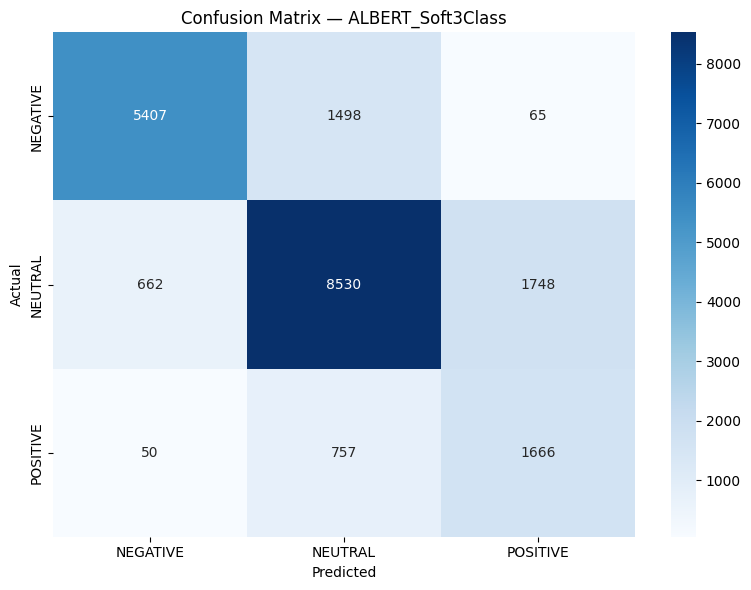

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only_soft_train/ALBERT_Soft3Class_roc_curve.png


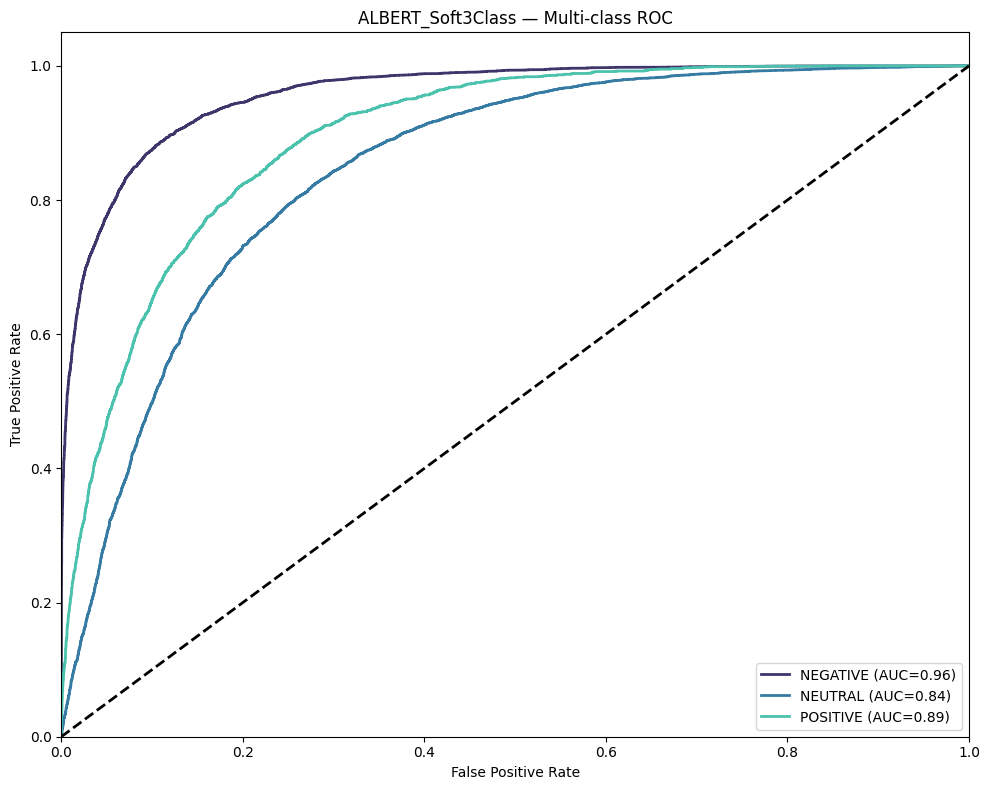

In [ ]:
albert_results = evaluate_with_ci(
    best_albert, test_loader_albert, "ALBERT", save_dir=str(OUTPUT_PATH)
)

## 3.5 BioBERT: Soft-label training

In [ ]:
print("\n" + "=" * 60)
print("BioBERT — Soft-Label Training (1111)")
print("=" * 60)


BioBERT — Soft-Label Training (1111)


### 3.5.1 Pre-tokenize

In [ ]:
BIOBERT_MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"
biobert_tokenizer = BertTokenizer.from_pretrained(BIOBERT_MODEL_NAME)
train_loader_biobert, val_loader_biobert, test_loader_biobert = \
    build_loaders(biobert_tokenizer, "BioBERT")

vocab.txt: 0.00B [00:00, ?B/s]


Tokenizing for BioBERT...


### 3.5.2 Hyperparameter tuning

In [ ]:
if RETRAIN:
    set_seed()
    start = time.time()

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Soft 3-Class"):
        hp = {
            "lr":      float(10 ** np.random.uniform(*param_space["lr"])),
            "epochs":  int(np.random.randint(*param_space["epochs"])),
            "dropout": float(np.random.uniform(*param_space["dropout"])),
        }

        base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
        model = TransformerClassifier(
            base, base.config.hidden_size,
            num_classes=NUM_CLASSES, dropout=hp["dropout"],
        )

        f1_val, model = train_soft_model(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model
            torch.save(model.state_dict(), MODEL_PATHS["biobert"]["model"])

        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    with open(MODEL_PATHS["biobert"]["params"], "w") as f:
        json.dump(best_params_biobert, f, indent=2)

else:
    with open(MODEL_PATHS["biobert"]["params"]) as f:
        best_params_biobert = json.load(f)
    base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
    best_biobert = TransformerClassifier(
        base, base.config.hidden_size,
        num_classes=NUM_CLASSES,
        dropout=best_params_biobert.get("dropout", 0.1),
    )
    best_biobert.load_state_dict(
        torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE)
    )

best_biobert.to(DEVICE)
best_biobert.eval()

BioBERT Soft 3-Class:   0%|          | 0/10 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/9 | Loss=0.8682 | Val F1=0.7565
  Epoch 2/9 | Loss=0.8045 | Val F1=0.7696
  Epoch 3/9 | Loss=0.7786 | Val F1=0.7515
  Epoch 4/9 | Loss=0.7599 | Val F1=0.7515
  Epoch 5/9 | Loss=0.7454 | Val F1=0.7603
  Early stopping at epoch 5.


BioBERT Soft 3-Class: 100%|██████████| 10/10 [1:18:31<00:00, 471.17s/it]

BioBERT tuning: 4711.7s | Best F1=0.7757
Best params: {'lr': 1.3271033162649868e-05, 'epochs': 7, 'dropout': 0.195692122900145}


TransformerClassifier(
  (base): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

### 3.5.3 Model Evaluation


--- BioBERT Test Evaluation (3-class) ---
              precision    recall  f1-score   support

    NEGATIVE     0.8662    0.7902    0.8265      6970
     NEUTRAL     0.7870    0.8258    0.8059     10940
    POSITIVE     0.5371    0.5528    0.5448      2473

    accuracy                         0.7805     20383
   macro avg     0.7301    0.7229    0.7257     20383
weighted avg     0.7838    0.7805    0.7813     20383

Weighted F1: 0.7813  95% CI [0.7759, 0.7868]
Macro AUC:   0.9015  95% CI [0.8981, 0.9052]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only_soft_train/BioBERT_Soft3Class_confusion_matrix.png


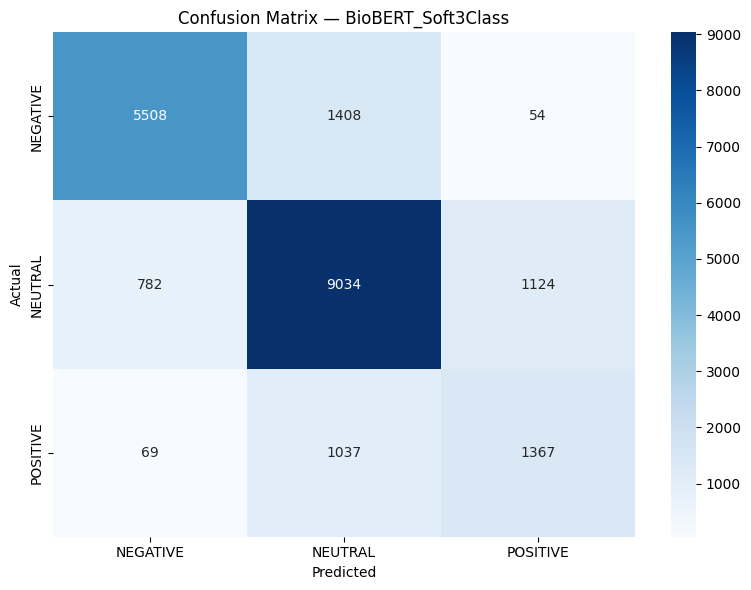

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only_soft_train/BioBERT_Soft3Class_roc_curve.png


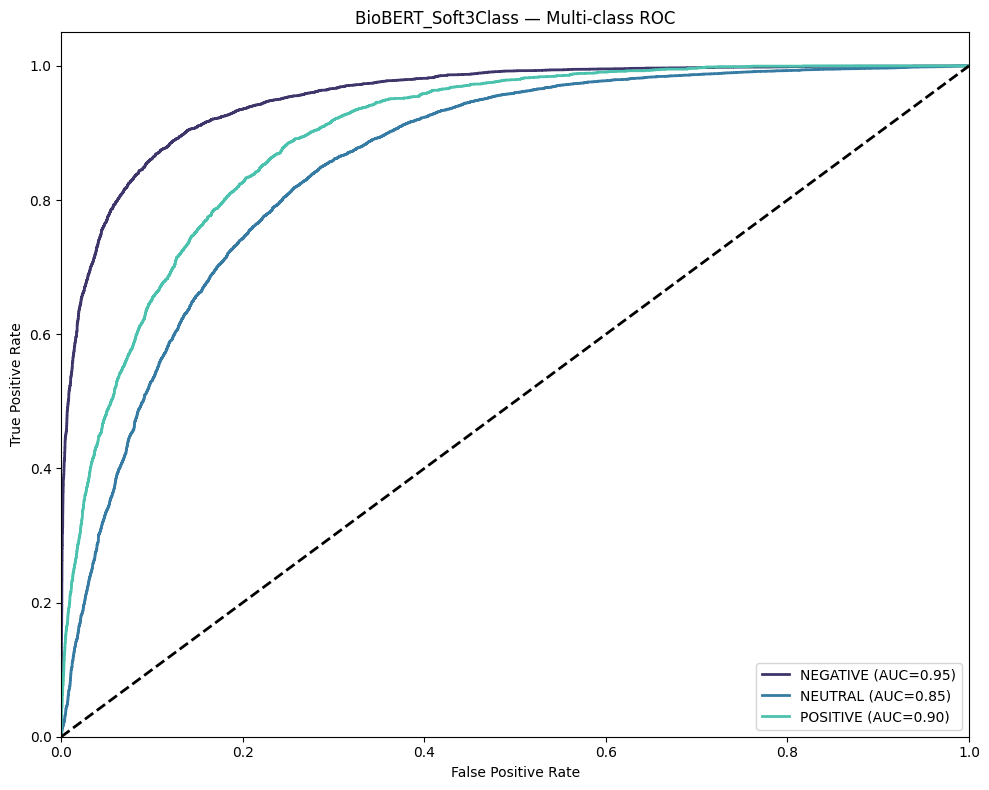

In [ ]:
biobert_results = evaluate_with_ci(
    best_biobert, test_loader_biobert, "BioBERT", save_dir=str(OUTPUT_PATH)
)

## 3.6 Save Prediction

In [ ]:
df_test_out = df_test[[TEXT_COLUMN, "y_hard_3class"]].copy()
df_test_out["albert_pred"] = albert_results["y_pred"]
df_test_out["biobert_pred"] = biobert_results["y_pred"]

# Add probability columns
for i, name in enumerate(CLASS_NAMES):
    df_test_out[f"albert_p_{name}"] = albert_results["y_prob"][:, i]
    df_test_out[f"biobert_p_{name}"] = biobert_results["y_prob"][:, i]

pred_path = OUTPUT_PATH / "test_predictions_soft3class.csv"
df_test_out.to_csv(pred_path, index=False)
print(f"\nSaved predictions → {pred_path}")

# ── Summary ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY — 3-Class Soft-Label (1111 aspect weights; soft-train, hard val/test)")
print("=" * 60)
for model_name, results in [("ALBERT", albert_results), ("BioBERT", biobert_results)]:
    print(f"\n{model_name}:")
    print(f"  Weighted F1: {results['f1_weighted']:.4f} "
          f"[{results['f1_ci'][0]:.4f}, {results['f1_ci'][1]:.4f}]")
    print(f"  Macro AUC:   {results['auc_macro']:.4f} "
          f"[{results['auc_ci'][0]:.4f}, {results['auc_ci'][1]:.4f}]")


Saved predictions → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/06_soft_label_uniform_weights/outputs_text_only_soft_train/test_predictions_soft3class.csv

SUMMARY — 3-Class Soft-Label (1111 aspect weights; soft-train, hard val/test)

ALBERT:
  Weighted F1: 0.7718 [0.7663, 0.7774]
  Macro AUC:   0.8995 [0.8962, 0.9029]

BioBERT:
  Weighted F1: 0.7813 [0.7759, 0.7868]
  Macro AUC:   0.9015 [0.8981, 0.9052]
